In [1]:
from sklearn.svm import SVC, SVR, NuSVR, NuSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, brier_score_loss

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import gc

import xgboost as xgb

import statsmodels as sm
import tqdm
from sklearn.metrics import roc_auc_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings
import catboost as cb
from collections import defaultdict

warnings.filterwarnings("ignore")
pd.set_option("display.max_column", 999)

In [2]:
#Load Data

In [3]:
# W -> women's basketball, M -> men's basketball
M_regular_results = pd.read_csv("MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv("MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv("MNCAATourneySeeds.csv")

W_regular_results = pd.read_csv("WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv("WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv("WNCAATourneySeeds.csv")

In [4]:
M_regular_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14


In [5]:
# join men's and women's data into one file
regular_results = pd.concat([M_regular_results, W_regular_results])
tourney_results = pd.concat([M_tourney_results, W_tourney_results])
seeds = pd.concat([M_seeds, W_seeds])

In [6]:
season = 2003  # change if you want different cutoff year for your models
regular_results = regular_results.loc[(regular_results["Season"] >= season) & (regular_results["Season"] <= 2025)]
tourney_results = tourney_results.loc[(tourney_results["Season"] >= season) & (tourney_results["Season"] <= 2025)]
seeds = seeds.loc[(seeds["Season"] >= season) & (seeds["Season"] <= 2025)]

In [7]:
#Define Home/Away, try other possibilities
wloc = {'H':1, 'A':-1, 'N': np.nan} #{'H':1, 'A':0, 'N': 0}  # {'H':1, 'A':-1, 'N': 0} #np.nan} #-1}
#wloc = {'H':1, 'A':-1, 'N': 0} #{'H':1, 'A':0, 'N': 0}  # {'H':1, 'A':-1, 'N': 0} #np.nan} #-1}
regular_results['WHome'] = regular_results['WLoc'].map(lambda x: wloc[x])
regular_results['WHome'].value_counts()

WHome
 1.0    114977
-1.0     66045
Name: count, dtype: int64

In [8]:
tourney_results['WHome'] = tourney_results['WLoc'].map(lambda x: wloc[x])
tourney_results['WHome'].value_counts()

WHome
 1.0    322
-1.0     57
Name: count, dtype: int64

In [9]:
#Prepare Dataset

In [10]:
# # double the dataset with swapped team positions in box scores
# def prepare_data(df):
#     df = df[["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT","WHome",
#             "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
#             "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]]
    

#     # adjustment factor for overtimes, as more stats are accumulated during overtimes
#     adjot = (40 + 5 * df["NumOT"]) / 40
#     adjcols = ["LScore", "WScore", 
#                "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
#                "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
#     for col in adjcols:
#         df[col] = df[col] / adjot    
    
#     dfswap = df.copy()
#     df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(df.columns)]
#     dfswap.columns = [x.replace("L", "T1_").replace("W", "T2_") for x in list(dfswap.columns)]
#     output = pd.concat([df, dfswap]).reset_index(drop=True)
#     output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
#     output["win"] = (output["PointDiff"] > 0) * 1
#     output["men_women"] = (output["T1_TeamID"].apply(lambda t: str(t).startswith("1"))) * 1  # 0: women, 1: men
#     return output

# regular_data = prepare_data(regular_results)
# tourney_data = prepare_data(tourney_results)

In [11]:
# double the dataset with swapped team positions in box scores
def prepare_data(df):
    df = df[["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT","WHome",
            "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
            "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]]
    

    # adjustment factor for overtimes, as more stats are accumulated during overtimes
    adjot = (40 + 5 * df["NumOT"]) / 40
    adjcols = ["LScore", "WScore", 
               "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
               "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
    for col in adjcols:
        df[col] = df[col] / adjot    
    
    dfswap = df.copy()
    df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(df.columns)]
    dfswap.columns = [x.replace("L", "T1_").replace("W", "T2_") for x in list(dfswap.columns)]
    #IMPORTANT UPDATES FOR HOMES
    df['T2_Home']=-df['T1_Home']
    dfswap['T1_Home']=-dfswap['T2_Home']
    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
    output["win"] = (output["PointDiff"] > 0) * 1
    output["men_women"] = (output["T1_TeamID"].apply(lambda t: str(t).startswith("1"))) * 1  # 0: women, 1: men
    return output

regular_data = prepare_data(regular_results)
tourney_data = prepare_data(tourney_results)

In [12]:
regular_data.columns

Index(['Season', 'DayNum', 'T2_TeamID', 'T2_Score', 'T1_TeamID', 'T1_Score',
       'NumOT', 'T1_Home', 'T2_FGM', 'T2_FGA', 'T2_FGM3', 'T2_FGA3', 'T2_FTM',
       'T2_FTA', 'T2_OR', 'T2_DR', 'T2_Ast', 'T2_TO', 'T2_Stl', 'T2_Blk',
       'T2_PF', 'T1_FGM', 'T1_FGA', 'T1_FGM3', 'T1_FGA3', 'T1_FTM', 'T1_FTA',
       'T1_OR', 'T1_DR', 'T1_Ast', 'T1_TO', 'T1_Stl', 'T1_Blk', 'T1_PF',
       'T2_Home', 'PointDiff', 'win', 'men_women'],
      dtype='object')

In [13]:
regular_data=regular_data[
['Season', 'DayNum', 'T1_TeamID', 'T1_Score', 'T2_TeamID', 'T2_Score', 'NumOT', 'PointDiff', 'win', 'men_women',
 'T1_FGM', 'T1_FGA', 'T1_FGM3', 'T1_FGA3', 'T1_FTM', 'T1_FTA', 'T1_OR', 'T1_DR', 'T1_Ast', 'T1_TO', 'T1_Stl', 'T1_Blk', 'T1_PF', 'T1_Home',
 'T2_FGM', 'T2_FGA', 'T2_FGM3', 'T2_FGA3', 'T2_FTM', 'T2_FTA', 'T2_OR', 'T2_DR', 'T2_Ast', 'T2_TO', 'T2_Stl', 'T2_Blk', 'T2_PF', 'T2_Home']
]

In [14]:
season = regular_data["Season"] == 2025
t1, t2 = 1182, 1433
match1 = (regular_data["T1_TeamID"] == t1) & (regular_data["T2_TeamID"] == t2)
match2 = (regular_data["T1_TeamID"] == t2) & (regular_data["T2_TeamID"] == t1)
regular_data.loc[season & (match1 | match2)]

,Season,DayNum,T1_TeamID,T1_Score,T2_TeamID,T2_Score,NumOT,PointDiff,win,men_women,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,T1_Home,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T2_Home
118444,2025,120,1433,71.0,1182,62.0,0,9.0,1,1,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,-1.0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,1.0
319034,2025,120,1182,62.0,1433,71.0,0,-9.0,0,1,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,1.0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,-1.0


### Seeds

In [15]:
# extract seed number from `Seed` field
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))
seeds

,Season,Seed,TeamID,seed
1154,2003,W01,1328,1
1155,2003,W02,1448,2
1156,2003,W03,1393,3
1157,2003,W04,1257,4
1158,2003,W05,1280,5
...,...,...,...,...
1739,2025,Z12,3193,12
1740,2025,Z13,3251,13
1741,2025,Z14,3195,14
1742,2025,Z15,3117,15


In [16]:
seeds_T1 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T2 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T1.columns = ["Season", "T1_TeamID", "T1_seed"]
seeds_T2.columns = ["Season", "T2_TeamID", "T2_seed"]

tourney_data = tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win", "men_women"]]
tourney_data = pd.merge(tourney_data, seeds_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, seeds_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["Seed_diff"] = tourney_data["T2_seed"] - tourney_data["T1_seed"]

tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff
0,2003,1421,1411,7.111111,1,1,16,16,0
1,2003,1112,1436,29.000000,1,1,1,16,15
2,2003,1113,1272,13.000000,1,1,10,7,-3
3,2003,1141,1166,6.000000,1,1,11,6,-5
4,2003,1143,1301,1.777778,1,1,8,9,1
...,...,...,...,...,...,...,...,...,...
4815,2025,3425,3163,-14.000000,0,0,1,2,1
4816,2025,3395,3400,-11.000000,0,0,2,1,-1
4817,2025,3417,3163,-34.000000,0,0,1,2,1
4818,2025,3400,3376,-17.000000,0,0,1,1,0


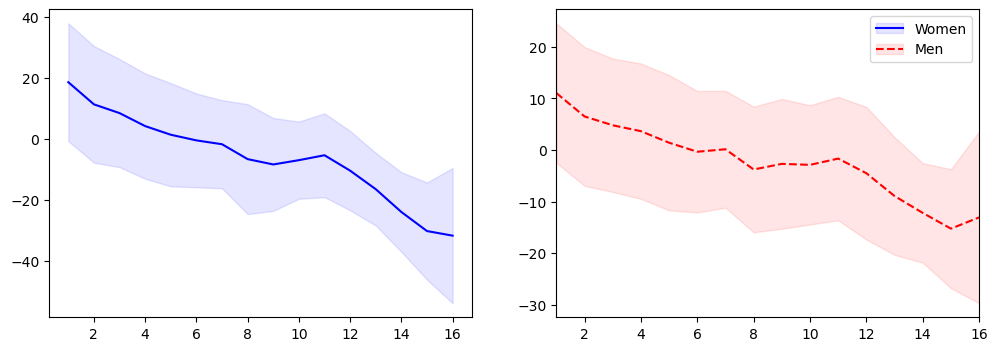

In [17]:
# let's see if __seed__ is predictive for predicting the point difference
tmpmean = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

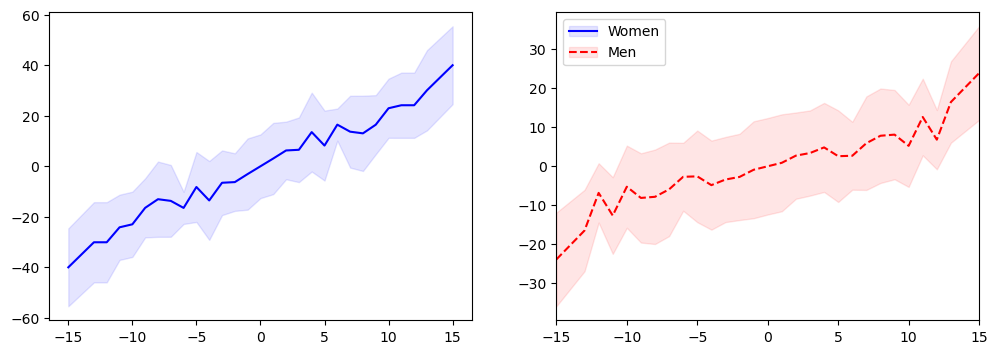

In [18]:
# let's see __seed difference__ is predictive for predicting the point difference
tmpmean = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

## <<- Medium difficulty features ->>

In [19]:
regular_data.columns

Index(['Season', 'DayNum', 'T1_TeamID', 'T1_Score', 'T2_TeamID', 'T2_Score',
       'NumOT', 'PointDiff', 'win', 'men_women', 'T1_FGM', 'T1_FGA', 'T1_FGM3',
       'T1_FGA3', 'T1_FTM', 'T1_FTA', 'T1_OR', 'T1_DR', 'T1_Ast', 'T1_TO',
       'T1_Stl', 'T1_Blk', 'T1_PF', 'T1_Home', 'T2_FGM', 'T2_FGA', 'T2_FGM3',
       'T2_FGA3', 'T2_FTM', 'T2_FTA', 'T2_OR', 'T2_DR', 'T2_Ast', 'T2_TO',
       'T2_Stl', 'T2_Blk', 'T2_PF', 'T2_Home'],
      dtype='object')

In [20]:
# box score columns, for which we want features to our model
boxcols = [
        "T1_Home","T2_Home",
    "T1_Score", "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
    "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF",
    "T2_Score", "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
    "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF",
    "PointDiff",
]

In [21]:
set(regular_data.columns.to_list())-set(boxcols)

{'DayNum', 'NumOT', 'Season', 'T1_TeamID', 'T2_TeamID', 'men_women', 'win'}

In [22]:
#Last 14 win ratio

#Return T/F here  to  indicate if win/lose or play/not in last 14 days
regular_data['win14days'] = (regular_data['DayNum'] > 118) & (regular_data['T1_Score'] > regular_data['T2_Score'])
regular_data['win14days'] = regular_data['win14days'].map(int)
regular_data['last14days'] = (regular_data['DayNum'] > 118).map(int)

def summarize_cols(x):
    return pd.Series({
                      'WinRatio14d': x['win14days'].sum() /  (1 + x['last14days'].sum()),
                     })

In [23]:
#Show the winratio of each team in last 14 days
ss_new = regular_data.groupby(['Season','T1_TeamID']).apply(summarize_cols, include_groups=False).reset_index()
ss_new.head()

,Season,T1_TeamID,WinRatio14d
0,2003,1102,0.25
1,2003,1103,0.25
2,2003,1104,0.25
3,2003,1105,0.00
4,2003,1106,0.40


In [24]:
ss_new['WinRatio14d'].unique()

array([0.25      , 0.        , 0.4       , 0.33333333, 0.5       ,
       0.75      , 0.2       , 0.66666667, 0.83333333, 0.6       ,
       0.71428571, 0.8       , 0.42857143, 0.57142857, 0.85714286,
       0.16666667, 0.625     , 0.375     ])

In [25]:
ss_new['season_team'] = ss_new['Season'].map(str) + '_' + ss_new['T1_TeamID'].map(str)
#create a dictionaryu for each team's win ratio in last 14 days
ratio_dict = dict(zip(ss_new['season_team'].tolist(),ss_new['WinRatio14d'].tolist()))
ss_new.head()

,Season,T1_TeamID,WinRatio14d,season_team
0,2003,1102,0.25,2003_1102
1,2003,1103,0.25,2003_1103
2,2003,1104,0.25,2003_1104
3,2003,1105,0.00,2003_1105
4,2003,1106,0.40,2003_1106


In [26]:
s = regular_data['Season'].tolist()
t1 = regular_data['T1_TeamID'].tolist()
t2 = regular_data['T2_TeamID'].tolist()
s1 = regular_data['T1_Score'].tolist()
s2 = regular_data['T2_Score'].tolist()

#Record the results of two games play against each other in total number of [win,lose]
#If two teams have not play any game, assume win/lose are both 1. Prevent infinity caused by divides by 0
d = defaultdict(lambda: [1,1])
for i in range(len(s)):
    tup = str(s[i])+'_'+str(t1[i])+'_'+str(t2[i])
    if s1[i] > s2[i]:
        d[tup][0] += 1
    else:
        d[tup][1] += 1

In [27]:
print(d['2003_1104_1328'])
print(d['2003_1328_1104'])

[2, 1]
[1, 2]


In [28]:
#based on previous matching reuslts, calculate winning odds
match_dict = defaultdict(lambda: 1)
for k,v in d.items():
    match_dict[k] = v[0]/(v[1])
#print(list(match_dict.items()))
print('done')

print(match_dict['2003_1104_1328'])
print(match_dict['2003_1328_1104'])

done
2.0
0.5


In [29]:
l1 = regular_data['T1_TeamID'].tolist()
l2 = regular_data['T2_TeamID'].tolist()
s0 = regular_data['Season'].tolist()
s1 = regular_data['T1_Score'].tolist()
s2 = regular_data['T2_Score'].tolist()
h1 = regular_data['T1_Home'].tolist()
h2 = regular_data['T2_Home'].tolist()

In [30]:
#See win/lose of each team at away
#home_dict uses [0,0] is fine since the assuption here is we will have statistics for each team
home_dict = defaultdict(lambda: [0,0]) #1,1])
for i in range(len(l1)):
    k = str(s0[i])+'_'+str(l1[i])
    if s1[i]>s2[i] and h1[i] == -1:
        home_dict[k][0]+= 1 #s1[i] #1
    elif s1[i]<s2[i] and h1[i] == -1:
        home_dict[k][1] += 1 #s2[i] #1

for i in range(len(l2)):
    k = str(s0[i])+'_'+str(l2[i])
    if s1[i]<s2[i] and h2[i] == -1:
        home_dict[k][0]+= 1 # s2[i] #1
    elif s1[i]>s2[i] and h2[i] == -1 :
        home_dict[k][1] += 1 #s1[i] #1

#win ratio of each team at away
#maybe should use default dict? If so what default value, 0.5?
away_dict = {}
for k,v in home_dict.items():
    away_dict[k] = v[0]/(v[0]+v[1])
print('done')


done


In [31]:
l1 = regular_data['T1_TeamID'].tolist()
l2 = regular_data['T2_TeamID'].tolist()
s0 = regular_data['Season'].tolist()
s1 = regular_data['T1_Score'].tolist()
s2 = regular_data['T2_Score'].tolist()

#See the win/lose statistics of each team in each season [0101..]
#No need for using for loop in l2 again. Since l1 already contains all info twice. If loop l2 again, each game is recorded 4 times. 
#No influence on win rate, but win times would be doubled

l_dict = defaultdict(list)
for i in range(len(l1)):
    k = str(s0[i])+'_'+str(l1[i])
    if s1[i]<s2[i]:
        l_dict[k].append(0)
    else:
        l_dict[k].append(1)
        
# for i in range(len(l2)):
#     k = str(s0[i])+'_'+str(l2[i])
#     if s1[i]>s2[i]:
#         l_dict[k].append(0)
#     else:
#         l_dict[k].append(1)

awins_dict = defaultdict(lambda: np.nan)
for k,v in l_dict.items():
    awins_dict[k] = np.mean(l_dict[k])

In [32]:
#对手强度修正
l_dict = defaultdict(list)
for i in range(len(l1)):
    k = str(s0[i])+'_'+str(l1[i])
    if s1[i]<s2[i]:
        l_dict[k].append(0) #-(1-awins_dict[str(s0[i])+'_'+str(l2[i])]))
    else:
        l_dict[k].append(awins_dict[str(s0[i])+'_'+str(l2[i])])
        
# for i in range(len(l2)):
#     k = str(s0[i])+'_'+str(l2[i])
#     if s1[i]>s2[i]:
#         l_dict[k].append(0) #-(1-awins_dict[str(s0[i])+'_'+str(l1[i])]))
#     else:
#         l_dict[k].append(awins_dict[str(s0[i])+'_'+str(l1[i])])

awins_dict = defaultdict(lambda: np.nan)
for k,v in l_dict.items():
    awins_dict[k] = np.mean(l_dict[k])

print('done')

done


In [33]:
# calculate season averages for boxcolumns (performance)
ss = regular_data.groupby(["Season", "T1_TeamID"])[boxcols].agg("mean").reset_index()

#求平均

ss_T1 = ss.copy()
ss_T1.columns = ["T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T1.columns)]
ss_T1 = ss_T1.rename({"T1_avg_Season": "Season", "T1_avg_TeamID": "T1_TeamID"}, axis=1)

#先把他定义为key,之后再update
ss_T1['T1_WinRatio14d'] = ss_T1['Season'].map(str) + '_' + ss_T1['T1_TeamID'].map(str)

#away_dict 客场胜率
ss_T1['T1_away_wins'] = ss_T1['T1_WinRatio14d'].map(away_dict)

#基于对手强度修正的胜率
ss_T1['T1_awins'] = ss_T1['T1_WinRatio14d'].map(awins_dict)

#过去14天胜率 update
#ss_T1['T1_loss_delta'] = ss_T1['T1_WinRatio14d'].map(loss_delta_dict)
ss_T1['T1_WinRatio14d'] = ss_T1['T1_WinRatio14d'].map(ratio_dict)

In [34]:
#Same for T2
ss_T2 = ss.copy()
ss_T2.columns = ["T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T2.columns)]
ss_T2 = ss_T2.rename({"T2_avg_Season": "Season", "T2_avg_TeamID": "T2_TeamID"}, axis=1)

ss_T2['T2_WinRatio14d'] = ss_T2['Season'].map(str) + '_' + ss_T2['T2_TeamID'].map(str)
ss_T2['T2_away_wins'] = ss_T2['T2_WinRatio14d'].map(away_dict)
ss_T2['T2_awins'] = ss_T2['T2_WinRatio14d'].map(awins_dict)
#ss_T2['T2_loss_delta'] = ss_T2['T2_WinRatio14d'].map(loss_delta_dict)
ss_T2['T2_WinRatio14d'] = ss_T2['T2_WinRatio14d'].map(ratio_dict)


#这样更好因为merge完以后T1是T1，T2是T2，columns不用改名了

tourney_data = pd.merge(tourney_data, ss_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, ss_T2, on=["Season", "T2_TeamID"], how="left")

#match_dict 是之前算的获胜odds(赔率)，若没有打过，就算1
tourney_data['laplace_matchup'] = tourney_data['Season'].map(str)+'_'+tourney_data['T1_TeamID'].map(str)+'_'+tourney_data['T2_TeamID'].map(str)
tourney_data['laplace_matchup'] = tourney_data['laplace_matchup'].map(match_dict)

tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_avg_Home,T1_avg_opponent_Home,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T1_WinRatio14d,T1_away_wins,T1_awins,T2_avg_Home,T2_avg_opponent_Home,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff,T2_WinRatio14d,T2_away_wins,T2_awins,laplace_matchup
0,2003,1421,1411,7.111111,1,1,16,16,0,-0.142857,0.142857,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,0.750000,0.125000,0.174245,0.076923,-0.076923,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148,0.714286,0.333333,0.233323,1.000000
1,2003,1112,1436,29.000000,1,1,1,16,15,0.111111,-0.111111,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,0.500000,0.916667,0.488861,-0.166667,0.166667,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655,0.750000,0.500000,0.255776,1.000000
2,2003,1113,1272,13.000000,1,1,10,7,-3,0.200000,-0.200000,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,0.500000,0.400000,0.296382,0.185185,-0.185185,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487,0.600000,0.636364,0.388420,1.000000
3,2003,1141,1166,6.000000,1,1,11,6,-5,-0.076923,0.076923,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,0.833333,0.642857,0.372517,0.214286,-0.214286,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990,0.800000,0.636364,0.411432,1.000000
4,2003,1143,1301,1.777778,1,1,8,9,1,0.12

In [35]:
tourney_data['laplace_matchup'].value_counts()

laplace_matchup
1.000000    4554
0.500000     122
2.000000     122
3.000000       6
0.333333       6
0.250000       3
4.000000       3
1.500000       2
0.666667       2
Name: count, dtype: int64

In [36]:
tourney_data[tourney_data['laplace_matchup']==4]

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_avg_Home,T1_avg_opponent_Home,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T1_WinRatio14d,T1_away_wins,T1_awins,T2_avg_Home,T2_avg_opponent_Home,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff,T2_WinRatio14d,T2_away_wins,T2_awins,laplace_matchup
3981,2011,3124,3401,-12.0,0,0,1,2,1,0.357143,-0.357143,80.060606,28.242424,59.666667,5.242424,13.363636,18.333333,24.666667,14.636364,30.333333,16.878788,14.000000,7.969697,7.121212,13.090909,53.696970,19.848485,61.878788,5.303030,20.393939,8.696970,12.454545,13.757576,20.606061,8.909091,16.515152,5.727273,2.666667,20.484848,26.363636,0.833333,0.777778,0.563800,0.043478,-0.043478,78.633333,29.466667,65.100000,4.900000,14.333333,14.800000,20.333333,16.433333,23.133333,16.666667,14.033333,10.833333,4.200000,18.566667,58.266667,19.800000,51.133333,4.500000,14.233333,14.166667,19.800000,11.100000,21.966667,10.100000,22.533333,5.700000,4.133333,18.566667,20.366667,0.5,0.727273,0.494500,4.0
3982,2011,3163,3323,-9.0,0,0,1,2,1,0.250000,-0.250000,77.696970,28.787879,57.424242,5.969697,16.575758,14.151515,18.393939,12.575758,29.606061,19.484848,15.333333,9.151515,4.424242,12.424242,49.969697,18.606061,57.909091,5.030303,18.151515,7.727273,11.272727,11.090909,18.363636,10.242424,16.727273,6.696970,2.696970,16.696970,27.727273,0.800000,0.916667,0.598230,0.172414,-0.172414,77.284848,28.339394,58.975758,3.333333,9.606061,17.272727,24.006061,15.193939,25.666667,17.181818,17.654545,13.206061,4.442424,16.521212,54.751515,19.909091,55.006061,4.127273,15.787879,10.806061,16.296970,12.678788,19.072727,11.127273,22.812121,8.454545,2.896970,18.781818,22.533333,0.4,0.583333,0.409741,4.0
4108,2013,3323,3163,-18.0,0,0,1,1,0,0.120000,-0.120000,79.765152,28.989899,63.380366,4.140783,12.394255,17.644571,22.138573,16.472222,26.724747,19.043876,15.425189,10.773359,3.847538,13.722222,56.761995,21.413194,58.165720,4.395202,15.145518,9.540404,13.282828,12.049242,20.311237,12.432449,20.333649,8.519886,4.376263,18.262942,23.003157,0.800000,1.000000,0.566021,0.185185,-0.185185,81.129477,30.696970,62.473829,8.487603,22.683196,11.247934,14.977961,13.876033,28.793388,20.567493,14.074380,10.382920,5.782369,12.746556,48.691460,17.953168,57.052342,4.688705,16.264463,8.096419,12.046832,11.787879,19.595041,10.278237,18.826446,6.079890,1.741047,14.969697,32.438017,0.4,0.909091,0.513664,4.0


In [37]:
regular_data[(regular_data['Season']==2013) & (regular_data['T1_TeamID']==3323) & (regular_data['T2_TeamID']==3163) ]

,Season,DayNum,T1_TeamID,T1_Score,T2_TeamID,T2_Score,NumOT,PointDiff,win,men_women,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,T1_Home,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T2_Home,win14days,last14days
136234,2013,61,3323,73.000000,3163,72.000000,0,1.000000,1,0,25.000000,66.000000,6.000000,12.000000,17.000000,24.000000,18.0,27.000000,12.000000,14.000000,4.000000,4.000000,16.0,-1.0,28.0,71.000000,5.000000,23.000000,11.000000,14.000000,17.000000,27.000000,21.000000,14.000000,8.000000,9.000000,17.000000,1.0,0,0
138847,2013,119,3323,69.818182,3163,63.272727,3,6.545455,1,0,25.454545,64.727273,0.727273,8.727273,18.181818,22.545455,16.0,19.636364,10.181818,15.272727,11.636364,1.454545,16.0,1.0,24.0,51.636364,5.090909,14.545455,10.181818,15.272727,10.909091,26.181818,16.727273,25.454545,11.636364,5.818182,19.636364,-1.0,1,1
139135,2013,127,3323,61.000000,3163,59.000000,0,2.000000,1,0,26.000000,63.000000,3.000000,12.000000,6.000000,6.000000,12.0,21.000000,14.000000,13.000000,6.000000,3.000000,13.0,NaN,25.0,57.000000,0.000000,5.000000,9.000000,11.000000,11.000000,25.000000,11.000000,17.000000,5.000000,2.000000,14.000000,NaN,1,1


## <<- Hard difficulty features ->>

In [38]:
# def expected_result(elo_a, elo_b):
#     return 1.0 / (1 + 10 ** ((elo_b - elo_a) / elo_width))

# def update_elo(winner_elo, loser_elo):
#     expected_win = expected_result(winner_elo, loser_elo)
#     change_in_elo = k_factor * (1 - expected_win)
#     winner_elo += change_in_elo
#     loser_elo -= change_in_elo
#     return winner_elo, loser_elo


# base_elo = 1000
# elo_width = 400
# k_factor = 100

# elos = []
# for season in sorted(set(seeds["Season"])):
#     ss = regular_data.loc[regular_data["Season"] == season]
#     #Only focus on win==1 to calculate every match once
#     ss = ss.loc[ss["win"] == 1].reset_index(drop=True)
#     teams = set(ss["T1_TeamID"]) | set(ss["T2_TeamID"])
#     elo = dict(zip(teams, [base_elo] * len(teams)))
#     for i in range(ss.shape[0]):
#         w_team, l_team = ss.loc[i, "T1_TeamID"], ss.loc[i, "T2_TeamID"]
#         w_elo, l_elo = elo[w_team], elo[l_team]
#         w_elo_new, l_elo_new = update_elo(w_elo, l_elo)
#         elo[w_team] = w_elo_new
#         elo[l_team] = l_elo_new
#     elo = pd.DataFrame.from_dict(elo, orient="index").reset_index()
#     elo = elo.rename({"index": "TeamID", 0: "elo"}, axis=1)
#     elo["Season"] = season
#     elos.append(elo)
# elos = pd.concat(elos)


In [39]:
# elos_T1 = elos.copy().rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
# elos_T2 = elos.copy().rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
# tourney_data = pd.merge(tourney_data, elos_T1, on=["Season", "T1_TeamID"], how="left")
# tourney_data = pd.merge(tourney_data, elos_T2, on=["Season", "T2_TeamID"], how="left")
# tourney_data["elo_diff"] = tourney_data["T1_elo"] - tourney_data["T2_elo"]

In [40]:
# tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_avg_Home,T1_avg_opponent_Home,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T1_WinRatio14d,T1_away_wins,T1_awins,T2_avg_Home,T2_avg_opponent_Home,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff,T2_WinRatio14d,T2_away_wins,T2_awins,laplace_matchup,T1_elo,T2_elo,elo_diff
0,2003,1421,1411,7.111111,1,1,16,16,0,-0.142857,0.142857,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,0.750000,0.125000,0.174245,0.076923,-0.076923,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148,0.714286,0.333333,0.233323,1.000000,1004.511285,1006.068840,-1.557555
1,2003,1112,1436,29.000000,1,1,1,16,15,0.111111,-0.111111,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,0.500000,0.916667,0.488861,-0.166667,0.166667,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655,0.750000,0.500000,0.255776,1.000000,1428.100063,1163.408934,264.691130
2,2003,1113,1272,13.000000,1,1,10,7,-3,0.200000,-0.200000,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,0.500000,0.400000,0.296382,0.185185,-0.185185,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487,0.600000,0.636364,0.388420,1.000000,1169.181611,1344.907733,-175.726122
3,2003,1141,1166,6.000000,1,1,11,6,-5,-0.076923,0.076923,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,0.833333,0.642857,0.372517,0.214286,-0.214286,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329

In [41]:
tmp = pd.merge(elos, tourney_data[['Season', 'T1_TeamID']].drop_duplicates(), 
               left_on = ['Season', 'TeamID'], 
               right_on = ['Season', 'T1_TeamID'],
               how = 'left')
tmp

,TeamID,elo,Season,T1_TeamID
0,1102,974.197367,2003,NaN
1,1103,983.942090,2003,NaN
2,1104,1111.862966,2003,1104.0
3,1105,634.480645,2003,NaN
4,1106,781.068089,2003,NaN
...,...,...,...,...
12874,3476,925.143292,2025,NaN
12875,3477,689.827556,2025,NaN
12876,3478,715.678296,2025,NaN
12877,3479,589.710611,2025,NaN


<Axes: xlabel='elo'>

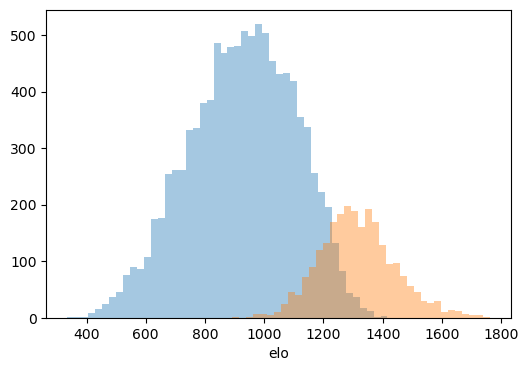

In [42]:
#pd.isull means this team did not go into tourney
plt.figure(figsize=(6,4))
seaborn.distplot(tmp.loc[pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)
seaborn.distplot(tmp.loc[~pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)

<Axes: xlabel='T1_seed', ylabel='T1_elo'>

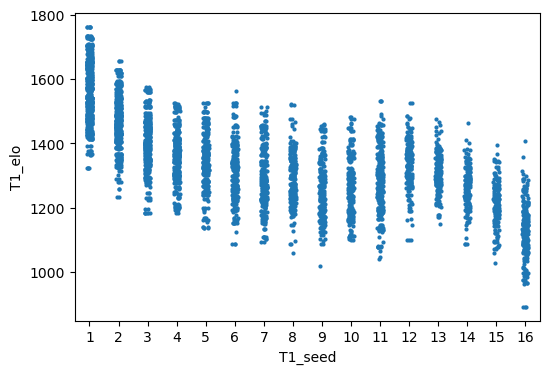

In [43]:
plt.figure(figsize=(6,4))
seaborn.stripplot(data = tourney_data, y = 'T1_elo', x = 'T1_seed', size=3)

<Axes: xlabel='Seed_diff', ylabel='elo_diff'>

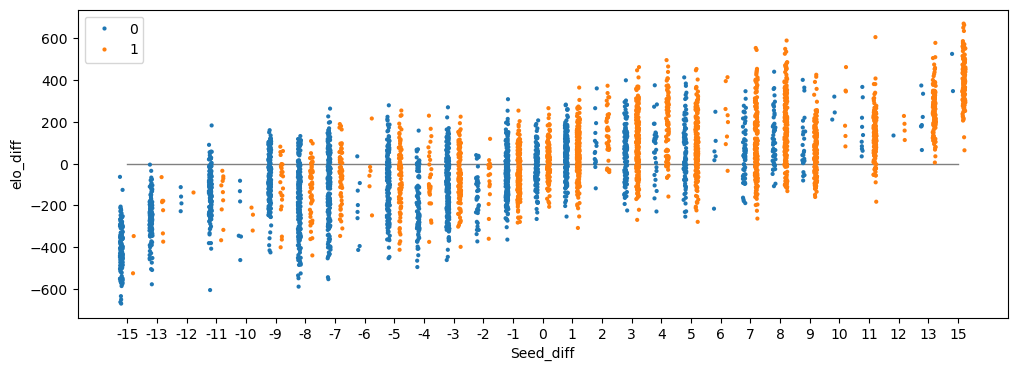

In [44]:
plt.figure(figsize=(12,4))
seaborn.stripplot(data = tourney_data, y = 'elo_diff', x = 'Seed_diff', hue='win', dodge=True, size=3)
seaborn.lineplot([0]*29,color='gray',lw = 1)

<Axes: xlabel='Seed_diff', ylabel='elo_diff'>

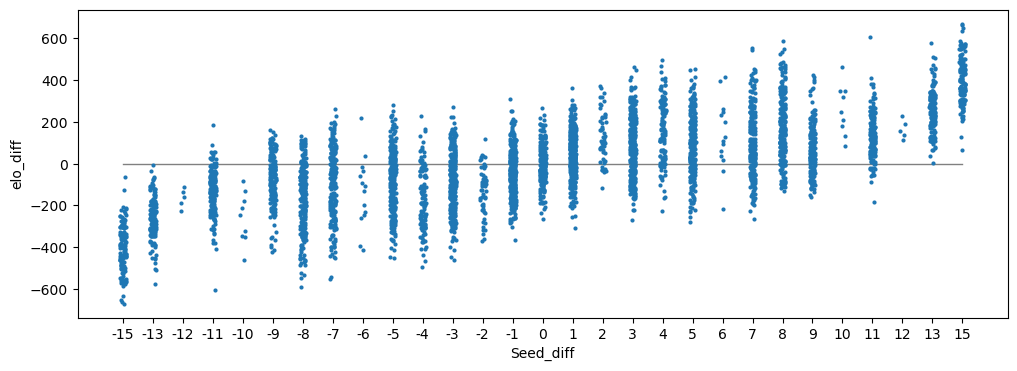

In [45]:
plt.figure(figsize=(12,4))
seaborn.stripplot(data = tourney_data, y = 'elo_diff', x = 'Seed_diff', size=3)
seaborn.lineplot([0]*29,color='gray',lw = 1)

In [38]:
#Find best K for elo
def expected_result(elo_a, elo_b):
    return 1.0 / (1 + 10 ** ((elo_b - elo_a) / elo_width))

def update_elo(winner_elo, loser_elo,k_factor):
    expected_win = expected_result(winner_elo, loser_elo)
    change_in_elo = k_factor * (1 - expected_win)
    winner_elo += change_in_elo
    loser_elo -= change_in_elo
    return winner_elo, loser_elo


base_elo = 1000
elo_width = 400
#k_factor = 100


def elo_fill(k):
    elos = []
    for season in sorted(set(seeds["Season"])):
        ss = regular_data.loc[regular_data["Season"] == season]
        ss = ss.loc[ss["win"] == 1].reset_index(drop=True)
        teams = set(ss["T1_TeamID"]) | set(ss["T2_TeamID"])
        elo = dict(zip(teams, [base_elo] * len(teams)))
        for i in range(ss.shape[0]):
            w_team, l_team = ss.loc[i, "T1_TeamID"], ss.loc[i, "T2_TeamID"]
            w_elo, l_elo = elo[w_team], elo[l_team]
            w_elo_new, l_elo_new = update_elo(w_elo, l_elo, k)
            elo[w_team] = w_elo_new
            elo[l_team] = l_elo_new
        elo = pd.DataFrame.from_dict(elo, orient="index").reset_index()
        elo = elo.rename({"index": "TeamID", 0: "elo"}, axis=1)
        elo["Season"] = season
        elos.append(elo)
    elos = pd.concat(elos)
    return elos

In [80]:
loss_dict={}

for k in range(40,161,10):
    tourney_copy=tourney_data.copy()
    test=elo_fill(k)
    
    elos_T1 = test.copy().rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
    elos_T2 = test.copy().rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
    
    tourney_copy = pd.merge(tourney_copy, elos_T1, on=["Season", "T1_TeamID"], how="left")
    tourney_copy = pd.merge(tourney_copy, elos_T2, on=["Season", "T2_TeamID"], how="left")
    
    #tourney_copy["elo_diff"] = tourney_copy["T1_elo"] - tourney_copy["T2_elo"]
    tourney_copy["expect"] = expected_result(tourney_copy["T1_elo"], tourney_copy["T2_elo"])
    
    season_loss=[]

    for season in tourney_copy['Season'].unique().tolist():
        sub=tourney_copy[(tourney_copy['Season']==season) & (tourney_copy['win']==1)]
        season_loss.append(((sub["expect"] - 1) ** 2).mean())
        
    loss_dict[k] = float(np.mean(season_loss))

In [71]:
tourney_data.head()

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_avg_Home,T1_avg_opponent_Home,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T1_WinRatio14d,T1_away_wins,T1_awins,T2_avg_Home,T2_avg_opponent_Home,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff,T2_WinRatio14d,T2_away_wins,T2_awins,laplace_matchup,T1_elo,T2_elo,elo_diff,T1_quality,T2_quality,diff_quality
0,2003,1421,1411,7.111111,1,1,16,16,0,-0.142857,0.142857,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,0.750000,0.125000,0.174245,0.076923,-0.076923,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148,0.714286,0.333333,0.233323,1.0,994.763477,1003.140568,-8.377090,-3.099741,2.115495,-5.215236
1,2003,1112,1436,29.000000,1,1,1,16,15,0.111111,-0.111111,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,0.500000,0.916667,0.488861,-0.166667,0.166667,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655,0.750000,0.500000,0.255776,1.0,1387.057304,1143.093901,243.963403,27.707625,8.728406,18.979218
2,2003,1113,1272,13.000000,1,1,10,7,-3,0.200000,-0.200000,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,0.500000,0.400000,0.296382,0.185185,-0.185185,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487,0.600000,0.636364,0.388420,1.0,1152.263291,1310.981377,-158.718086,19.701429,19.004846,0.696583
3,2003,1141,1166,6.000000,1,1,11,6,-5,-0.076923,0.076923,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,0.833333,0.642857,0.372517,0.214286,-0.214286,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609

In [73]:
tourney_copy=tourney_data.copy()
tourney_copy=tourney_copy.drop(['T1_elo', 'T2_elo'], axis=1)
test=elo_fill(80)

loss_dict={}
elos_T1 = test.copy().rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
elos_T2 = test.copy().rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)

tourney_copy = pd.merge(tourney_copy, elos_T1, on=["Season", "T1_TeamID"], how="left")
tourney_copy = pd.merge(tourney_copy, elos_T2, on=["Season", "T2_TeamID"], how="left")

#tourney_copy["elo_diff"] = tourney_copy["T1_elo"] - tourney_copy["T2_elo"]
tourney_copy["expect"] = expected_result(tourney_copy["T1_elo"], tourney_copy["T2_elo"])

season_loss=[]

for season in tourney_copy['Season'].unique().tolist():
    sub=tourney_copy[(tourney_copy['Season']==season) & (tourney_copy['win']==1)]
    season_loss.append(((sub["expect"] - 1) ** 2).mean())
    
loss_dict[k] = float(np.mean(season_loss))

In [75]:
season_loss

[np.float64(0.22474302831351212),
 np.float64(0.20404658004063225),
 np.float64(0.18339974038629037),
 np.float64(0.20498740829197887),
 np.float64(0.17984604754703276),
 np.float64(0.16454753425376756),
 np.float64(0.18484011213962492),
 np.float64(0.19549770419044518),
 np.float64(0.19876818216819891),
 np.float64(0.18081889633550288),
 np.float64(0.2258176067960147),
 np.float64(0.2009884580143392),
 np.float64(0.1866364229338725),
 np.float64(0.21365618066624514),
 np.float64(0.21138452137507005),
 np.float64(0.197393644634276),
 np.float64(0.18007869555245798),
 np.float64(0.23663348693439212),
 np.float64(0.21618515859591764),
 np.float64(0.21827125238493994),
 np.float64(0.20650475927856066),
 np.float64(0.17644433863860506)]

    k_factor  mean_loss
0         80   0.199613
1         90   0.199733
2         70   0.200014
3        100   0.200274
4         60   0.201076
5        110   0.201158
6        120   0.202329
7         50   0.203006
8        130   0.203739
9        140   0.205352
10        40   0.206115
11       150   0.207135
12       160   0.209060
best_k: 80
best_loss: 0.1996131708850762


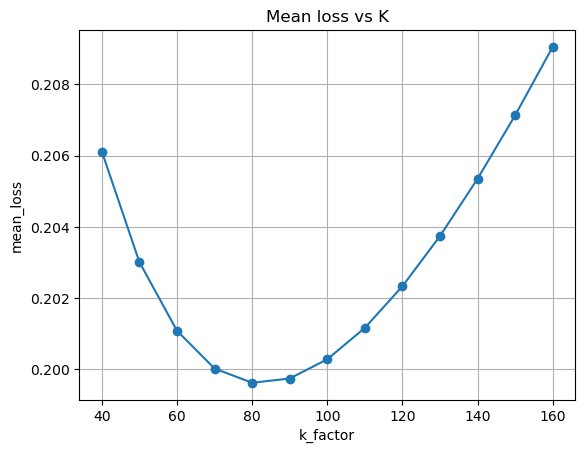

In [81]:
loss_df = pd.DataFrame(
    [{"k_factor": k, "mean_loss": v} for k, v in loss_dict.items()]
).sort_values("mean_loss", ascending=True).reset_index(drop=True)

print(loss_df)

best_k = int(loss_df.loc[0, "k_factor"])
best_loss = float(loss_df.loc[0, "mean_loss"])
print("best_k:", best_k)
print("best_loss:", best_loss)

plot_df = loss_df.sort_values("k_factor")
plt.figure()
plt.plot(plot_df["k_factor"], plot_df["mean_loss"], marker="o")
plt.xlabel("k_factor")
plt.ylabel("mean_loss")
plt.title("Mean loss vs K")
plt.grid(True)
plt.show()

In [39]:
base_elo = 1000
elo_width = 400
k_factor = 80

elos = []
for season in sorted(set(seeds["Season"])):
    ss = regular_data.loc[regular_data["Season"] == season]
    #Only focus on win==1 to calculate every match once
    ss = ss.loc[ss["win"] == 1].reset_index(drop=True)
    teams = set(ss["T1_TeamID"]) | set(ss["T2_TeamID"])
    elo = dict(zip(teams, [base_elo] * len(teams)))
    for i in range(ss.shape[0]):
        w_team, l_team = ss.loc[i, "T1_TeamID"], ss.loc[i, "T2_TeamID"]
        w_elo, l_elo = elo[w_team], elo[l_team]
        w_elo_new, l_elo_new = update_elo(w_elo, l_elo,80)
        elo[w_team] = w_elo_new
        elo[l_team] = l_elo_new
    elo = pd.DataFrame.from_dict(elo, orient="index").reset_index()
    elo = elo.rename({"index": "TeamID", 0: "elo"}, axis=1)
    elo["Season"] = season
    elos.append(elo)
elos = pd.concat(elos)

In [40]:
elos_T1 = elos.copy().rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
elos_T2 = elos.copy().rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
tourney_data = pd.merge(tourney_data, elos_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, elos_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["elo_diff"] = tourney_data["T1_elo"] - tourney_data["T2_elo"]

<Axes: xlabel='elo'>

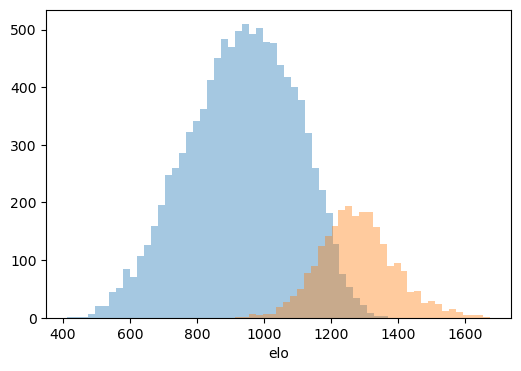

In [41]:
tmp = pd.merge(elos, tourney_data[['Season', 'T1_TeamID']].drop_duplicates(), 
               left_on = ['Season', 'TeamID'], 
               right_on = ['Season', 'T1_TeamID'],
               how = 'left')

plt.figure(figsize=(6,4))
seaborn.distplot(tmp.loc[pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)
seaborn.distplot(tmp.loc[~pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)

<Axes: xlabel='T1_seed', ylabel='T1_elo'>

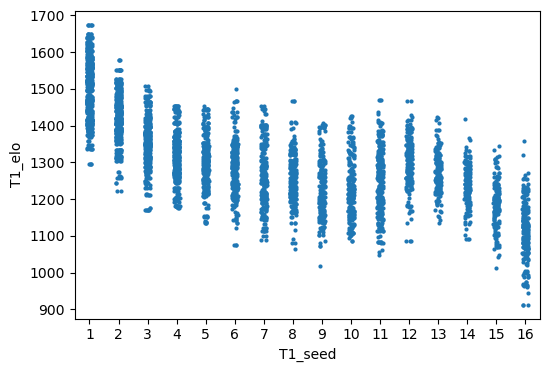

In [42]:
plt.figure(figsize=(6,4))
seaborn.stripplot(data = tourney_data, y = 'T1_elo', x = 'T1_seed', size=3)

<Axes: xlabel='Seed_diff', ylabel='elo_diff'>

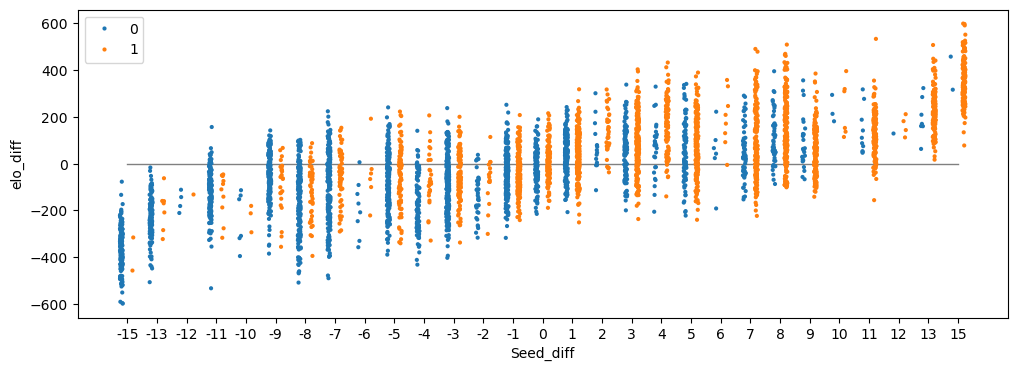

In [43]:
plt.figure(figsize=(12,4))
seaborn.stripplot(data = tourney_data, y = 'elo_diff', x = 'Seed_diff', hue='win', dodge=True, size=3)
seaborn.lineplot([0]*29,color='gray',lw = 1)

## <<- Hardest difficulty features ->>

In [44]:
regular_data["ST1"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
regular_data["ST2"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)
seeds_T1["ST1"] = seeds_T1.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
seeds_T2["ST2"] = seeds_T2.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)


In [45]:
seeds_T1

,Season,T1_TeamID,T1_seed,ST1
1154,2003,1328,1,2003/1328
1155,2003,1448,2,2003/1448
1156,2003,1393,3,2003/1393
1157,2003,1257,4,2003/1257
1158,2003,1280,5,2003/1280
...,...,...,...,...
1739,2025,3193,12,2025/3193
1740,2025,3251,13,2025/3251
1741,2025,3195,14,2025/3195
1742,2025,3117,15,2025/3117


In [46]:
seeds_T2

,Season,T2_TeamID,T2_seed,ST2
1154,2003,1328,1,2003/1328
1155,2003,1448,2,2003/1448
1156,2003,1393,3,2003/1393
1157,2003,1257,4,2003/1257
1158,2003,1280,5,2003/1280
...,...,...,...,...
1739,2025,3193,12,2025/3193
1740,2025,3251,13,2025/3251
1741,2025,3195,14,2025/3195
1742,2025,3117,15,2025/3117


In [47]:
print(len(seeds_T1["ST1"]))
print(len(set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])))

2896
2896


In [48]:
import statsmodels.api as sm
# collect tourney teams
st = set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])
# append non-tourney teams which were able to beat tourney team at least once
st = st | set(regular_data.loc[(regular_data["T1_Score"] > regular_data["T2_Score"]) & 
                               (regular_data["ST2"].isin(st)), "ST1"])

def team_quality(season, men_women):
    # mixed effects: fixed intercept=0, random slope
    formula = "PointDiff~-1+T1_TeamID+T2_TeamID"
    glm = sm.GLM.from_formula(
        formula=formula,
        data=dt.loc[(dt["Season"] == season) & (dt["men_women"] == men_women), :],
        family=sm.families.Gaussian(),
    ).fit()
    
    quality = pd.DataFrame(glm.params).reset_index()
    quality.columns = ["TeamID", "quality"]
    quality["quality"] = quality["quality"]
    quality["Season"] = season
    quality = quality.loc[quality.TeamID.str.contains("T1_")].reset_index(drop=True)
    quality["TeamID"] = quality["TeamID"].apply(lambda x: x[10:14]).astype(int)
    return quality


glm_quality = []

dt = regular_data.loc[regular_data["ST1"].isin(st) | regular_data["ST2"].isin(st)]
dt["T1_TeamID"] = dt["T1_TeamID"].astype(str)
dt["T2_TeamID"] = dt["T2_TeamID"].astype(str)
dt.loc[~dt["ST1"].isin(st), "T1_TeamID"] = "0000"
dt.loc[~dt["ST2"].isin(st), "T2_TeamID"] = "0000"
seasons = sorted(set(seeds["Season"]))
for s in tqdm.tqdm(seasons, unit="season"):
    if s >= 2010:  # min season for women
        glm_quality.append(team_quality(s, 0))
    if s >= 2003:  # min season for men
        glm_quality.append(team_quality(s, 1))

glm_quality = pd.concat(glm_quality).reset_index(drop=True)

glm_quality_T1 = glm_quality.copy()
glm_quality_T2 = glm_quality.copy()
glm_quality_T1.columns = ["T1_TeamID", "T1_quality", "Season"]
glm_quality_T2.columns = ["T2_TeamID", "T2_quality", "Season"]
tourney_data = pd.merge(tourney_data, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["diff_quality"] = tourney_data["T1_quality"] - tourney_data["T2_quality"]

100%|██████████| 22/22 [04:35<00:00, 12.54s/season]


In [49]:
glm_quality

,TeamID,quality,Season
0,0,2.142730e-14,2003
1,1102,1.016058e+01,2003
2,1103,3.540853e+00,2003
3,1104,2.014129e+01,2003
4,1105,-4.081386e+00,2003
...,...,...,...
7796,1473,-2.599197e+00,2025
7797,1474,4.698754e+00,2025
7798,1475,-4.384087e+00,2025
7799,1476,-1.966107e+00,2025


<Axes: ylabel='T1_quality'>

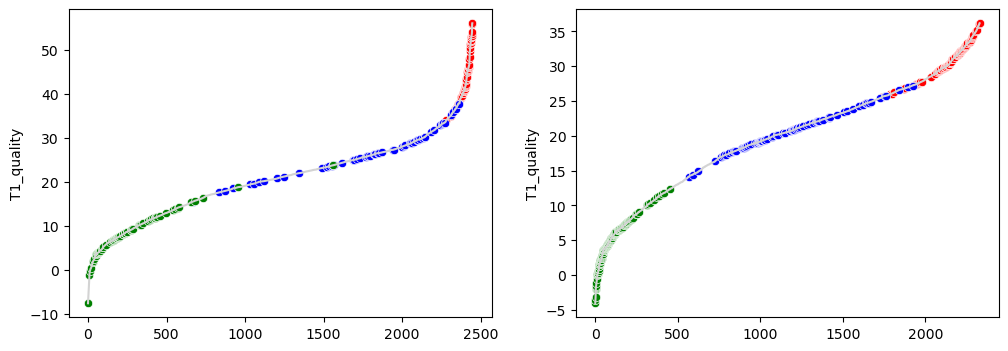

In [50]:
tmp = (
    tourney_data[["Season", "men_women", "T1_seed", "T1_quality"]]
    .drop_duplicates()
    .sort_values("T1_quality")
    .reset_index(drop=True)
)

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

seaborn.lineplot(tmp.loc[tmp["men_women"] == 0, "T1_quality"], color="lightgray", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[0])

seaborn.lineplot(tmp.loc[tmp["men_women"] == 1, "T1_quality"], color="lightgray", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[1])


In [51]:
tmp["QualitySeed"] = (
    (tmp.groupby(["Season", "men_women"])["T1_quality"].rank(ascending=False) // 4 + 1).clip(1, 16).astype(int)
)
pd.pivot_table(data=tmp, index="T1_seed", columns="QualitySeed", values="men_women", aggfunc="count").fillna(0).astype(int).style.bar(color="#5fba7d", vmin=0, vmax=50)

QualitySeed,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
T1_seed,,,,,,,,,,,,,,,,
1,81,47,12,4,1,1,1,0,1,0,0,0,0,0,0,0
2,18,52,43,21,7,5,2,0,0,0,0,0,0,0,0,0
3,6,18,36,31,26,17,6,3,0,4,1,0,0,0,0,0
4,5,15,24,26,19,23,21,9,3,2,1,0,0,0,0,0
5,0,7,15,25,22,19,23,14,8,4,8,3,0,0,0,0
6,1,3,8,15,25,31,15,19,10,10,6,4,1,0,0,0
7,0,2,3,8,19,12,21,23,23,15,12,8,2,0,0,0
8,0,0,3,7,6,17,20,23,19,24,16,6,7,0,0,0
9,0,2,0,6,10,9,12,19,27,25,20,11,5,1,1,0


In [52]:
print("Seed AUC    :", np.round(roc_auc_score(1 - tourney_data["win"], tourney_data["T1_seed"] - tourney_data["T2_seed"]), 3))
print("Quality AUC :", np.round(roc_auc_score(tourney_data["win"], tourney_data["T1_quality"] - tourney_data["T2_quality"]), 3))

Seed AUC    : 0.811
Quality AUC : 0.829


In [53]:
# who is better, experts or statistics, by season
for s in sorted(set(tourney_data['Season'])):
    st = tourney_data['Season'] == s
    print(s, 
          a:=np.round(roc_auc_score(1-tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_seed'] - tourney_data.loc[st, 'T2_seed']),3),
          b:=np.round(roc_auc_score(tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_quality'] - tourney_data.loc[st, 'T2_quality']),3),
          np.where(a>b, '', 'Q')
         )

2003 0.807 0.779 
2004 0.823 0.81 
2005 0.792 0.811 Q
2006 0.75 0.781 Q
2007 0.902 0.838 
2008 0.817 0.851 Q
2009 0.84 0.843 Q
2010 0.804 0.808 Q
2011 0.789 0.816 Q
2012 0.828 0.855 Q
2013 0.792 0.819 Q
2014 0.779 0.816 Q
2015 0.85 0.87 Q
2016 0.787 0.825 Q
2017 0.842 0.851 Q
2018 0.786 0.794 Q
2019 0.85 0.88 Q
2021 0.78 0.818 Q
2022 0.77 0.794 Q
2023 0.781 0.793 Q
2024 0.839 0.839 Q
2025 0.891 0.901 Q


In [54]:
regular_data["ST1"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
regular_data["ST2"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)

In [55]:
seeds_T1["ST1"] = seeds_T1.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
seeds_T2["ST2"] = seeds_T2.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)

In [56]:
seeds_T1

,Season,T1_TeamID,T1_seed,ST1
1154,2003,1328,1,2003/1328
1155,2003,1448,2,2003/1448
1156,2003,1393,3,2003/1393
1157,2003,1257,4,2003/1257
1158,2003,1280,5,2003/1280
...,...,...,...,...
1739,2025,3193,12,2025/3193
1740,2025,3251,13,2025/3251
1741,2025,3195,14,2025/3195
1742,2025,3117,15,2025/3117


In [57]:
seeds_T2

,Season,T2_TeamID,T2_seed,ST2
1154,2003,1328,1,2003/1328
1155,2003,1448,2,2003/1448
1156,2003,1393,3,2003/1393
1157,2003,1257,4,2003/1257
1158,2003,1280,5,2003/1280
...,...,...,...,...
1739,2025,3193,12,2025/3193
1740,2025,3251,13,2025/3251
1741,2025,3195,14,2025/3195
1742,2025,3117,15,2025/3117


In [58]:
regular_data

,Season,DayNum,T1_TeamID,T1_Score,T2_TeamID,T2_Score,NumOT,PointDiff,win,men_women,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,T1_Home,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T2_Home,win14days,last14days,ST1,ST2
0,2003,10,1104,68.0,1328,62.0,0,6.0,1,1,27.0,58.0,3.0,14.0,11.0,18.0,14.0,24.0,13.0,23.0,7.0,1.0,22.0,NaN,22.0,53.0,2.0,10.0,16.0,22.0,10.0,22.0,8.0,18.0,9.0,2.0,20.0,NaN,0,0,2003/1104,2003/1328
1,2003,10,1272,70.0,1393,63.0,0,7.0,1,1,26.0,62.0,8.0,20.0,10.0,19.0,15.0,28.0,16.0,13.0,4.0,4.0,18.0,NaN,24.0,67.0,6.0,24.0,9.0,20.0,20.0,25.0,7.0,12.0,8.0,6.0,16.0,NaN,0,0,2003/1272,2003/1393
2,2003,11,1266,73.0,1437,61.0,0,12.0,1,1,24.0,58.0,8.0,18.0,17.0,29.0,17.0,26.0,15.0,10.0,5.0,2.0,25.0,NaN,22.0,73.0,3.0,26.0,14.0,23.0,31.0,22.0,9.0,12.0,2.0,5.0,23.0,NaN,0,0,2003/1266,2003/1437
3,2003,11,1296,56.0,1457,50.0,0,6.0,1,1,18.0,38.0,3.0,9.0,17.0,31.0,6.0,19.0,11.0,12.0,14.0,2.0,18.0,NaN,18.0,49.0,6.0,22.0,8.0,15.0,17.0,20.0,9.0,19.0,4.0,3.0,23.0,NaN,0,0,2003/1296,2003/1457
4,2003,11,1400,77.0,1208,71.0,0,6.0,1,1,30.0,61.0,6.0,14.0,11.0,13.0,17.0,22.0,12.0,14.0,4.0,4.0,20.0,NaN,24.0,62.0,6.0,16.0,17.0,27.0,21.0,15.0,12.0,10.0,7.0,1.0,14.0,NaN,0,0,2003/1400,2003/1208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401175,2025,131,3413,66.0,3471,75.0,0,-9.0,0,0,24.0,67.0,9.0,29.0,9.0,14.0,9.0,26.0,14.0,10.0,6.0,5.0,22.0,1.0,26.0,62.0,4.0,19.0,19.0,28.0,8.0,31.0,10.0,11.0,6.0,1.0,20.0,-1.0,0,1,2025/3413,2025/3471
401176,2025,132,3476,49.0,3192,66.0,0,-17.0,0,0,21.0,57.0,4.0,20.0,3.0,4.0,14.0,22.0,14.0,17.0,4.0,1.0,17.0,-1.0,23.0,55.0,3.0,21.0,17.0,18.0,10.0,22.0,11.0,9.0,8.0,1.0,8.0,1.0,0,1,2025/3476,2025/3192
401177,2025,132,3119,62.0,3250,74.0,0,-12.0,0,0,25.0,56.0,6.0,17.0,6.0,10.0,8.0,13.0,10.0,10.0,5.0,0.0,20.0,-1.0,27.0,45.0,5.0,14.0,15.0,17.0,5.0,25.0,15.0,15.0,6.0,0.0,12.0,1.0,0,1,2025/3119,2025/3250
401178,2025,132,3125,62.0,3293,83.0,0,-21.0,0,0,24.0,68.0,2.0,21.0,12.0,14.0,12.0,22.0,11.0,7.0,5.0,0.0,16.0,NaN,28.0,54.0,14.0,28.0,13.0,15.0,5.0,33.0,21.0,13.0,2.0,3.0,15.0,NaN,0,1,2025/3125,2025/3293


In [59]:
# collect tourney teams
st = set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])

In [60]:
st

{'2004/3397',
 '2025/3163',
 '2024/1173',
 '2014/1438',
 '2018/3453',
 '2025/3250',
 '2014/1393',
 '2024/3394',
 '2014/3460',
 '2006/3277',
 '2019/1326',
 '2024/3333',
 '2017/3390',
 '2007/1401',
 '2022/1395',
 '2017/3235',
 '2005/1448',
 '2022/1124',
 '2021/1361',
 '2011/1242',
 '2013/1160',
 '2015/3181',
 '2019/1459',
 '2017/3401',
 '2008/1129',
 '2012/3336',
 '2011/1401',
 '2018/1276',
 '2019/3332',
 '2004/1435',
 '2022/3439',
 '2006/1133',
 '2023/1345',
 '2009/1127',
 '2013/1266',
 '2007/3415',
 '2017/3400',
 '2016/1396',
 '2013/1195',
 '2006/1206',
 '2017/1332',
 '2008/1257',
 '2006/3194',
 '2010/3163',
 '2010/3326',
 '2004/1418',
 '2023/3241',
 '2023/3218',
 '2012/3357',
 '2008/3143',
 '2022/1417',
 '2012/1125',
 '2010/3323',
 '2009/1268',
 '2019/1209',
 '2023/3276',
 '2013/1299',
 '2004/3345',
 '2012/1163',
 '2010/1373',
 '2012/1246',
 '2015/3338',
 '2015/1124',
 '2007/1257',
 '2009/3113',
 '2009/1328',
 '2014/1196',
 '2004/1150',
 '2018/1211',
 '2019/3120',
 '2012/3355',
 '2006

In [61]:
# append non-tourney teams which were able to beat tourney team at least once
st = st | set(regular_data.loc[(regular_data["T1_Score"] > regular_data["T2_Score"]) & 
                               (regular_data["ST2"].isin(st)), "ST1"])

In [62]:
regular_data['T1_TeamID'].dtype

dtype('int64')

<Axes: >

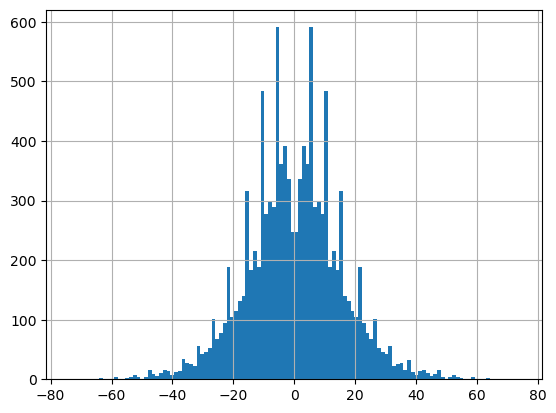

In [63]:
regular_data[(regular_data['Season']==2025) & (regular_data['men_women']==1)]["PointDiff"].hist(bins=120)

In [64]:
import statsmodels.api as sm

subset = regular_data[
    (regular_data['Season'] == 2025) & 
    (regular_data['men_women'] == 1)
].copy()

subset["T1_TeamID"] = subset["T1_TeamID"].astype(str)
subset["T2_TeamID"] = subset["T2_TeamID"].astype(str)

glm = sm.GLM.from_formula(
    formula="PointDiff ~ -1 + T1_TeamID + T2_TeamID",
    data=subset,
    family=sm.families.Gaussian()
).fit()

In [65]:
glm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              PointDiff   No. Observations:                11282
Model:                            GLM   Df Residuals:                    10555
Model Family:                Gaussian   Df Model:                          726
Link Function:               Identity   Scale:                          124.35
Method:                          IRLS   Log-Likelihood:                -42840.
Date:                Fri, 06 Mar 2026   Deviance:                   1.3125e+06
Time:                        14:00:09   Pearson chi2:                 1.31e+06
No. Iterations:                     3   Pseudo R-squ. (CS):             0.6409
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
T1_TeamID[1101]    2.109e-14      2.991   7.05e-15      1.000      -5.863       5.863
T1_TeamID[1102]      -2.2883      2.978     -0.768      0.442      -8.124       3.548
T1_TeamID[1103]       9.0313      2.981      3.030      0.002       3.189      14.874
T1_TeamID[1104]      31.3987      2.940     10.681      0.000      25.637      37.161
T1_TeamID[1105]     -14.7692      3.046     -4.849      0.000     -20.738      -8.800
T1_TeamID[1106]      -3.7828      2.953     -1.281      0.200      -9.571       2.005
T1_TeamID[1107]      -3.9585      3.024     -1.309      0.191      -9.886       1.969
T1_TeamID[1108]      -8.2784      2.993     -2.766      0.006     -14.144      -2.413
T1_TeamID[1110]      -1.5750      3.008     -0.524      0.601      -7.470       4.320
T1_TeamID[1111]       2.9761      3.040      0.979      0.328      -2.982       8.934
T1_TeamID[1112]      28.5916      2.926      9.773      0.000      22.858      34.326
T1_TeamID[1113]      16.7304      2.960      5.652      0.000      10.929      22.532
T1_TeamID[1114]      -1.1661      3.033     -0.385      0.701      -7.110       4.778
T1_TeamID[1115]     -18.6371      3.039     -6.132      0.000     -24.594     -12.681
T1_TeamID[1116]      22.0858      2.941      7.511      0.000      16.322      27.849
T1_TeamID[1117]      10.6357      2.947      3.609      0.000       4.860      16.411
T1_TeamID[1119]      -7.0605      3.076     -2.295      0.022     -13.090      -1.031
T1_TeamID[1120]      35.0403      2.941     11.913      0.000      29.275      40.805
T1_TeamID[1122]      -3.7209      3.004     -1.239      0.215      -9.608       2.166
T1_TeamID[1123]      -2.3102      3.076     -0.751      0.453      -8.338       3.718
T1_TeamID[1124]      24.8782      2.912      8.543      0.000      19.171      30.586
T1_TeamID[1125]       7.5132      2.984      2.518      0.012       1.665      13.362
T1_TeamID[1126]      -4.5342      2.952     -1.536      0.125     -10.319       1.251
T1_TeamID[1127]      -7.7935      3.070     -2.539      0.011     -13.810      -1.777
T1_TeamID[1129]      19.3478      2.965      6.526      0.000      13.537      25.158
T1_TeamID[1130]       5.6770      2.987      1.901      0.057      -0.177      11.531
T1_TeamID[1131]      -5.3493      3.025     -1.768      0.077     -11.278       0.580
T1_TeamID[1132]      -3.8984      3.021     -1.290      0.197      -9.820       2.023
T1_TeamID[1133]      11.6709      2.969      3.931      0.000       5.852      17.490
T1_TeamID[1135]       0.5174      3.153      0.164      0.870      -5.663       6.698
T1_TeamID[1136]       3.7430      2.998      1.249      0.212      -2.132       9.618
T1_TeamID[1137]       0.4208      2.979      0.141      0.888      -5.418       6.260
T1_TeamID[1138]      -9.4686      3.047     -3.107      0.002     -15.441

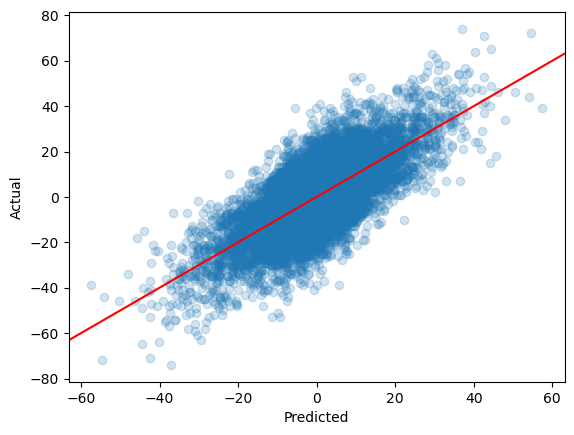

In [66]:
y = subset["PointDiff"]
y_pred = glm.predict(subset)

import matplotlib.pyplot as plt
plt.scatter(y_pred, y, alpha=0.2)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.axline((0,0),(1,1), color='red')
plt.show()

In [67]:
T1,   T2,   T1_Score, T2_Score, PointDiff, T1_Home, T2_Home
1001, 1002, 60,       50,       10       , 1,       Nan

1002, 1001, 50,        50,      -10,     , Nan,     -1
PointDiff=PointDiff
PointDiff=-1*PointDiff



SyntaxError: invalid syntax (1717046905.py, line 4)